# Compulsory Assignment 2: Convolutional neural networks

Please fill out the group name, number, members and optionally the name below.

**Group number**: 26\
**Group member 1**: Milad Tootoonchi\
**Group member 2**: Sania Minaipour\
**Group member 3**: Makka Dulgaeva  


# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 

# Introduction 
In this assignment, you will build a Convolutional Neural Network (CNN) to classify images of natural scenes from around the world.
Dataset: Intel-image-classification
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

This Data contains around 25k images of size 150x150 distributed under 6 categories.
{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

#### In CA2, we use only 3 classes "buildings", "forest", "sea".

This data was initially published on https://datahack.analyticsvidhya.com by Intel to host a Image classification Challenge.
## Landscape Pictures

Example image:


<center><img src="20497.jpg" width="500" height="400"></center>


## Assignment structure

1. Part 0: Setup & Data
2. Part 1: Baseline CNN (Clean Data)
3. Part 2: Choose Your Robustness Challenges
4. Part 3: Results & Comparison

```

## Library imports

In [70]:
# Feel free to add or remove libraries as you want
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import tensorflow.keras as ks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models
from utilities import f1_score, resize_dataset, plot_training_history, add_gaussian_noise, add_motion_blur

# Part 0: Setup & Data, CNN for Landscape Picture dataset 
### NOTE FOR STUDENTS:

Do not forget to change the path of root_dir below so it points to the Intel folder which contains the dataset inside your CA2 directory.
### Example:

Windows: r"C:\Users\yourname\...\CA2\Intel"

Mac/Linux: "/home/yourname/CA2/Intel"
 
## Loading DATASET

In [74]:
import importlib
import utilities

# Force reload the updated utilities.py
importlib.reload(utilities)

from utilities import load_intel_dataset


In [75]:
# Load dataset
data = load_intel_dataset(
    root_dir=r"C:\Users\milad\Documents\Progging\Machine-Learning-Deep-Learning\DAT300\CA2\Intel",
    img_size=(224, 224),
    selected_classes=["buildings", "forest", "sea"],  #  only 3 classes
    verbose=1
    
)

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
class_names      = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape,   y_val.shape)
print("Test:",  X_test.shape,  y_test.shape)

# Show number of images per class
def count_per_class(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{split_name} set class distribution:")
    for cls, cnt in zip(unique, counts):
        print(f"  {class_names[cls]}: {cnt}")

count_per_class(y_train, "Train")
count_per_class(y_val,   "Val")
count_per_class(y_test,  "Test")


[train] Loaded 500/6736 images
[train] Loaded 1000/6736 images
[train] Loaded 1500/6736 images
[train] Loaded 2000/6736 images
[train] Loaded 2500/6736 images
[train] Loaded 3000/6736 images
[train] Loaded 3500/6736 images
[train] Loaded 4000/6736 images
[train] Loaded 4500/6736 images
[train] Loaded 5000/6736 images
[train] Loaded 5500/6736 images
[train] Loaded 6000/6736 images
[train] Loaded 6500/6736 images
[train] Loaded 6736/6736 images
[test] Loaded 500/1421 images
[test] Loaded 1000/1421 images
[test] Loaded 1421/1421 images
Final shapes → Train: (6062, 224, 224, 3), Val: (674, 224, 224, 3), Test: (1421, 224, 224, 3)
Classes: ['buildings', 'forest', 'sea']
Train: (6062, 224, 224, 3) (6062,)
Val: (674, 224, 224, 3) (674,)
Test: (1421, 224, 224, 3) (1421,)

Train set class distribution:
  buildings: 1972
  forest: 2044
  sea: 2046

Val set class distribution:
  buildings: 219
  forest: 227
  sea: 228

Test set class distribution:
  buildings: 437
  forest: 474
  sea: 510


## Preprocessing


In [76]:

# Normalizing input between [0,1]
X_train = X_train.astype("float32") / 255.0 if X_train.size else X_train
X_val   = X_val.astype("float32")   / 255.0 if X_val.size else X_val
X_test  = X_test.astype("float32")  / 255.0 if X_test.size else X_test

# Converting targets from numbers to categorical format
if y_train is not None and y_train.size:
    num_classes = len(np.unique(y_train))
    y_train = ks.utils.to_categorical(y_train, num_classes)

if y_val is not None and y_val.size:
    y_val = ks.utils.to_categorical(y_val, num_classes)

if y_test is not None and y_test.size:
    y_test = ks.utils.to_categorical(y_test, num_classes)
    
print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)
    


X_train shape: (6062, 224, 224, 3)
X_val shape: (674, 224, 224, 3)
X_test shape: (1421, 224, 224, 3)


## Part 1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture for Landscape Pictures (RGB): 

--------------------------
The LeNet architecture takes a 32×32×C image as input, where C is the number of color channels. You may use resize_dataset() and f1_score() from utilities.py¶

Input & resizing: Resize all images to 32×32 and use C = 3 channels (RGB).
If you choose a different input size, update the intermediate shapes accordingly, but keep the LeNet-5 pattern (Conv → Pool → Conv → Pool → FC → FC → FC).

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected (output):** **`num_classes`**. **Activation:** softmax

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [50]:
def f1(y_true, y_pred):
    y_pred = tf.cast(tf.argmax(y_pred, axis = -1), tf.int32)
    y_true = tf.cast(tf.argmax(y_true, axis = -1), tf.int32)

    # Convert to one-hot for matching shapes
    y_pred = tf.one_hot(y_pred, depth = tf.shape(y_true)[-1])
    y_true = tf.one_hot(y_true, depth = tf.shape(y_true)[-1])

    tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
    fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, tf.float32))
    fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), tf.float32))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return f1

In [51]:
X_train_resized = resize_dataset(X_train)
X_test_resized = resize_dataset(X_test)
X_val_resized = resize_dataset(X_val)

def lanet():
    inputs = layers.Input(shape = (32, 32, 3))

    x = layers.Conv2D(6, kernel_size = (5, 5), padding = 'valid', activation = 'relu')(inputs)
    x = layers.MaxPool2D(pool_size = (2, 2), strides = 2)(x)

    x = layers.Conv2D(16, kernel_size = (5, 5), padding = 'valid', activation = 'relu')(x)
    x = layers.MaxPool2D(pool_size = (2, 2), strides = 2)(x)

    # Flattening
    x = layers.Flatten()(x)
    
    x = layers.Dense(120, activation = 'relu')(x)
    x = layers.Dense(84, activation = 'relu')(x)
    x = layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs = inputs, outputs = x)

    model.compile(
        optimizer = ks.optimizers.Adam(),
        loss = ks.losses.CategoricalCrossentropy(),
        metrics = ["accuracy", f1]
    )

    return model


### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs


In [52]:
model = lanet()

history = model.fit(
    X_train_resized, y_train,
    batch_size = 64,
    epochs = 20,
    validation_data = (X_val_resized, y_val),
    verbose = 1
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4812 - f1: 0.4814 - loss: 0.9917 - val_accuracy: 0.6365 - val_f1: 0.6332 - val_loss: 0.7669
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6041 - f1: 0.6040 - loss: 0.8227 - val_accuracy: 0.6395 - val_f1: 0.6410 - val_loss: 0.7475
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6255 - f1: 0.6255 - loss: 0.7929 - val_accuracy: 0.6380 - val_f1: 0.6384 - val_loss: 0.7458
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6217 - f1: 0.6218 - loss: 0.7871 - val_accuracy: 0.6499 - val_f1: 0.6485 - val_loss: 0.7244
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6445 - f1: 0.6449 - loss: 0.7685 - val_accuracy: 0.6617 - val_f1: 0.6611 - val_loss: 0.7168
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6602 - f1: 0.6603 - loss: 0.7513 - val_accuracy: 0.6691 - val_f1: 0.6682 - val_loss: 0.6929
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0

### Task 1.1.3 
Experiment with different architectures of your choice. Vary the number of filters, try different kernel sizes, add more layers, dropout, early stopping, and modify the fully connected layers. Report the best performance you achieve.

In [53]:
# SqueezeNet Architecture
def fire_module(x, squeeze_filters, expand_filters):
    # Squeeze layer (1×1)
    squeeze = layers.Conv2D(squeeze_filters, (1, 1), activation = 'relu', padding = 'valid')(x)
    
    # Expand layer (1×1 and 3×3)
    expand_1x1 = layers.Conv2D(expand_filters, (1, 1), activation = 'relu', padding = 'valid')(squeeze)
    expand_3x3 = layers.Conv2D(expand_filters, (3, 3), activation = 'relu', padding = 'same')(squeeze)
    
    # Concatenate
    output = layers.Concatenate(axis = -1)([expand_1x1, expand_3x3])
    return output


def squeezenet(num_classes, size):
    inputs = layers.Input(shape = (size, size, 3))

    x = layers.Conv2D(96, (7, 7), strides = (2, 2), activation = 'relu', padding = 'same')(inputs)
    x = layers.MaxPooling2D((3, 3), strides = (2, 2), padding = 'same')(x)

    x = fire_module(x, 16, 64)
    x = fire_module(x, 16, 64)
    x = fire_module(x, 32, 128)
    x = layers.MaxPooling2D((3, 3), strides = (2, 2), padding = 'same')(x)

    x = fire_module(x, 32, 128)
    x = fire_module(x, 48, 192)
    x = fire_module(x, 48, 192)
    x = fire_module(x, 64, 256)
    x = layers.MaxPooling2D((3, 3), strides = (2, 2), padding = 'same')(x)

    x = fire_module(x, 64, 256)
    x = layers.Dropout(0.5)(x)
    x = layers.Conv2D(num_classes, (1, 1), padding = 'valid')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)


    model = models.Model(inputs, outputs)

    model.compile(optimizer = ks.optimizers.Adam(),
                  loss = ks.losses.CategoricalCrossentropy(),
                  metrics = ['accuracy', f1])
    return model

In [54]:
# Training
size = 32
X_train_resized = resize_dataset(X_train)
X_test_resized = resize_dataset(X_test)
X_val_resized = resize_dataset(X_val)
model = squeezenet(num_classes, size)

history_squeeze = model.fit(
    X_train_resized, y_train,
    batch_size = 64,
    epochs = 20,
    validation_data = (X_val_resized, y_val),
    verbose = 1
)

print(f"The val_accuracy score: {history_squeeze.history['val_accuracy'][-1]}")
print(f"The val_f1 score: {history_squeeze.history['val_f1'][-1]}")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.3261 - f1: 0.3261 - loss: 1.0991 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0986
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3286 - f1: 0.3287 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3311 - f1: 0.3312 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3342 - f1: 0.3340 - loss: 1.0987 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3345 - f1: 0.3348 - loss: 1.0987 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.3360 - f1: 0.3363 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accu

In [55]:
# Inception model
def simple_inception_block(x, f1 = 32, f3 = 32, f5 = 16, pool_proj = 16):
    # 1x1
    path1 = layers.Conv2D(f1, (1,1), padding = 'same', activation = 'relu')(x)

    # 3x3
    path2 = layers.Conv2D(f3, (3,3), padding = 'same', activation = 'relu')(x)

    # 5x5
    path3 = layers.Conv2D(f5, (5,5), padding = 'same', activation = 'relu')(x)

    # 3x3 max pooling + 1x1 conv
    path4 = layers.MaxPooling2D((3,3), strides = (1,1), padding = 'same')(x)
    path4 = layers.Conv2D(pool_proj, (1,1), padding = 'same', activation = 'relu')(path4)

    # Concatenate along channels
    return layers.concatenate([path1, path2, path3, path4], axis = -1)


def inception(num_classes, size):
    inputs = layers.Input(shape = (size, size, 3))

    # Stem
    x = layers.Conv2D(32, (3,3), strides = (2,2), padding = 'same', activation = 'relu')(inputs)
    x = layers.Conv2D(32, (3,3), padding = 'same', activation = 'relu')(x)
    x = layers.MaxPooling2D((3,3), strides = (2,2), padding = 'same')(x)

    # Inception blocks
    x = simple_inception_block(x, 32, 32, 16, 16)
    x = simple_inception_block(x, 64, 48, 16, 16)
    x = layers.MaxPooling2D((3,3), strides = (2,2), padding = 'same')(x)

    x = simple_inception_block(x, 64, 64, 32, 32)
    x = simple_inception_block(x, 64, 64, 32, 32)
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer = ks.optimizers.Adam(),
        loss = ks.losses.CategoricalCrossentropy(),
        metrics = ['accuracy', f1]
    )
    
    return model


In [56]:
# Training
size = 32
X_train_resized = resize_dataset(X_train)
X_test_resized = resize_dataset(X_test)
X_val_resized = resize_dataset(X_val)
model = inception(num_classes, size)

history_inception = model.fit(
    X_train_resized, y_train,
    batch_size = 64,
    epochs = 20,
    validation_data = (X_val_resized, y_val),
    verbose = 1
)

print(f"The val_accuracy score: {history_inception.history['val_accuracy'][-1]}")
print(f"The val_f1 score: {history_inception.history['val_f1'][-1]}")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.3311 - f1: 0.3312 - loss: 1.0987 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3345 - f1: 0.3348 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3378 - f1: 0.3378 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3428 - f1: 0.3425 - loss: 1.0985 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 1.0985
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3373 - f1: 0.3376 - loss: 1.0986 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3274 - f1: 0.3273 - loss: 1.0987 - val_accuracy: 0.3368 - val_f1: 0.3350 - val_loss: 1.0985
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accu

In [59]:
# ResNet
def residual_block(x, filters, stride = 1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding = 'same', activation ='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(filters, (3, 3), padding = 'same', activation=None)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding = 'same', activation = None)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def resnet(num_classes, size):
    inputs = layers.Input(shape = (size, size, 3))

    x = layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer = ks.optimizers.Adam(),
        loss = ks.losses.CategoricalCrossentropy(),
        metrics = ['accuracy', f1]
    )
    return model


In [60]:
# Training
size = 32
X_train_resized = resize_dataset(X_train)
X_test_resized = resize_dataset(X_test)
X_val_resized = resize_dataset(X_val)
model = resnet(num_classes, size)

history_resnet = model.fit(
    X_train_resized, y_train,
    batch_size = 64,
    epochs = 20,
    validation_data = (X_val_resized, y_val),
    verbose = 1
)

print(f"The val_accuracy score: {history_resnet.history['val_accuracy'][-1]}")
print(f"The val_f1 score: {history_resnet.history['val_f1'][-1]}")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 267ms/step - accuracy: 0.7842 - f1: 0.7845 - loss: 0.5768 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 2.7073
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.8669 - f1: 0.8668 - loss: 0.3521 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 5.2614
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 24s 248ms/step - accuracy: 0.8837 - f1: 0.8832 - loss: 0.3051 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 5.4028
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 235ms/step - accuracy: 0.9099 - f1: 0.9099 - loss: 0.2492 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 2.6898
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.9200 - f1: 0.9200 - loss: 0.2231 - val_accuracy: 0.3383 - val_f1: 0.3414 - val_loss: 2.9549
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.9304 - f1: 0.9303 - loss: 0.1967 - val_accuracy: 0.4525 - val_f1: 0.4545 - val_loss: 1.6920
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 199m

The best preformance comes from the ResNet architecture, with both validation accuracy and -f1-score on around 0.927. Even though this model overfittet extremely at first, it got more generlized for each epoch, and still did better than the other models.

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history 
- Plot the training/validation accuracy and loss curves (plot_training_history() is in utilities.py).
- Report the final validation accuracy (f1_score() is in utilities.py).

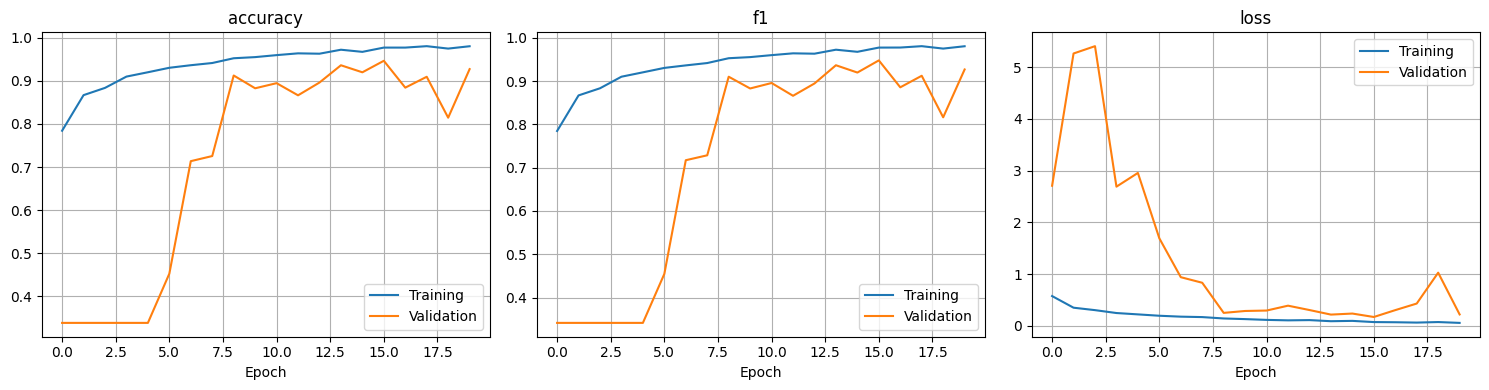

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Validation F1 Score (ResNet): 0.9732


In [65]:
""" assuming we're only plotting and validating for the best model (resnet)"""
plot_training_history(history_resnet)

y_val_pred_resnet = model.predict(X_val_resized)

val_f1_resnet = f1_score(y_val, y_val_pred_resnet)
print(f"Validation F1 Score (ResNet): {val_f1_resnet:.4f}")

### Task 1.2.2 Evaluate on the test dataset
- Report test accuracy (and F1 score (f1_score() is in utilities.py)).

In [66]:
y_test_pred_resnet = model.predict(X_test_resized)

test_f1_resnet = f1_score(y_test, y_test_pred_resnet)
print(f"Test F1 Score (ResNet): {test_f1_resnet:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Test F1 Score (ResNet): 0.9787


### Task 1.2.3 Create a confusion matrix for both training and testing data
- Visualize confusion matrices.
- Do the test data and train data predict the same items wrong?

190/190 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step


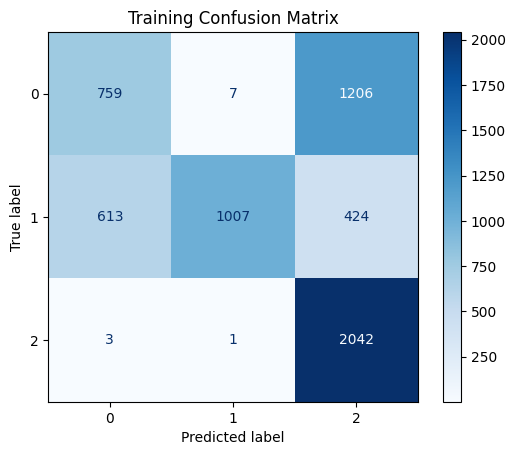

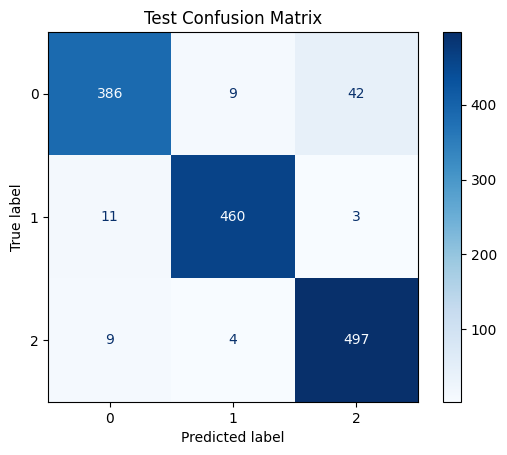

In [68]:

y_train_pred = model.predict(X_train)

y_train_pred_labels = np.argmax(y_train_pred, axis=1)
y_train_true_labels = np.argmax(y_train, axis=1)
cm_train = confusion_matrix(y_train_true_labels, y_train_pred_labels)
ConfusionMatrixDisplay(cm_train).plot(cmap = 'Blues')
plt.title("Training Confusion Matrix")
plt.show()

y_test_pred_labels = np.argmax(y_test_pred_resnet, axis=1)
y_test_true_labels = np.argmax(y_test, axis=1)
cm_test = confusion_matrix(y_test_true_labels, y_test_pred_labels)
ConfusionMatrixDisplay(cm_test).plot(cmap = 'Blues')
plt.title("Test Confusion Matrix")
plt.show()

The train data predicts more items wrong in general. The train data confuses the sea labels alot with builidng and sometimes with forrests. And the train data also confuses some buildings with forrests. The test data does not confuse as much items like the train data, however that can maybe be a result of the test data being smaller. The test data has the same confusion tendencies as the train data.

## Part 2: Robustness (choose two or more), You may use add_gaussian_noise() and add_motion_blur() from utilities.py

### Task 2.1 Data Augmentation (training-time)
- Implement an augmentation pipeline.
- Train a model with augmentation and compare against the baseline from Part 1.

### Task 2.2 Noise Robustness (test-time corruptions)
- Create corrupted versions of the test images and evaluate the baseline model:
  - Gaussian noise
  - Motion blur
- Report accuracy on the clean test set vs. each corrupted test set.

### Task 2.3  Discussion (no coding)
- Which noise types affect the model most?
- What techniques could improve robustness (data augmentation, adversarial training, denoising pre-processing, larger models)?

In [71]:
# 2.1
datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

# Fit to your training data
datagen.fit(X_train_resized)

# Use the augmented data for training
model.fit(
    datagen.flow(X_train_resized, y_train, batch_size = 64),
    epochs = 20,
    validation_data=(X_val, y_val)
)

Epoch 1/20


c:\Users\milad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 48s 473ms/step - accuracy: 0.8865 - f1: 0.8865 - loss: 0.3242 - val_accuracy: 0.5579 - val_f1: 0.5312 - val_loss: 1.5150
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.9068 - f1: 0.9070 - loss: 0.2557 - val_accuracy: 0.8294 - val_f1: 0.7912 - val_loss: 0.4708
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 449ms/step - accuracy: 0.9139 - f1: 0.9139 - loss: 0.2355 - val_accuracy: 0.7077 - val_f1: 0.6747 - val_loss: 0.8617
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 451ms/step - accuracy: 0.9233 - f1: 0.9232 - loss: 0.2212 - val_accuracy: 0.7092 - val_f1: 0.6761 - val_loss: 0.6705
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.9264 - f1: 0.9263 - loss: 0.2164 - val_accuracy: 0.7760 - val_f1: 0.7401 - val_loss: 0.5803
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 446ms/step - accuracy: 0.9258 - f1: 0.9259 - loss: 0.2054 - val_accuracy: 0.7878 - val_f1: 0.7514 - val_loss: 0.5034
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 453ms/step - ac

The validation accuracy for this data landed on 0.835 and f1 on around 0.797, this is less than the model we got on part 1 with 0.927 on both accuracy and f1 validation. This model on part 2.1 also overfitted alot more.

In [81]:
# 2.2
X_test_gaussian = add_gaussian_noise(X_test_resized)
X_test_motion = add_motion_blur(X_test_resized)

_, clean, f1_clean= model.evaluate(X_test_resized, y_test, verbose = 0)
_, gaussian, f1_gaussian = model.evaluate(X_test_gaussian, y_test, verbose = 0)
_, motion, f1_motion = model.evaluate(X_test_motion, y_test, verbose = 0)

print("Scores: accuracy | f1-score")
print(f"Clean: {clean} | {f1_clean}")
print(f"Gaussian Noise: {gaussian} | {f1_gaussian}")
print(f"Motion Blur: {motion} | {f1_motion}")

Scores: accuracy | f1-score
Clean: 0.935960590839386 | 0.9337606430053711
Gaussian Noise: 0.30752989649772644 | 0.30347222089767456
Motion Blur: 0.4060520827770233 | 0.4138889014720917


#### 2.3
The gaussian noice affected the model most. since the model was only trained on clean data, it was not used to noisy images. This made the accuracy and F1 score drop a lot. To make the model better, we could train it with noisy images or use methods to remove the noise before testing. Or we could use the data augmentation instead since the scores did not drop as much as gaussian noise or motion blur.

# Part 3: Results & Comparison
- Summarize results (table/plot):
  - Baseline (clean) vs. Augmented (if attempted)
  - Clean vs. each corrupted test set (Task 2.2)
- Brief discussion:
  - Which corruptions hurt most, and why?
  - Did augmentation help? Which transforms mattered?
  - What would you try next (e.g., stronger augmentation, adversarial training, denoising pre-processing, larger models, early stopping, ensembling)?

| Model / Data Type | Accuracy | F1 |
| - | - | - |
| Baseline  | 0.936 | 0.934 |
| Augmented | 0.835 | 0.797 |
| Gaussian Noise | 0.308 | 0.303 |
| Motion Blur | 0.406 | 0.414 |


The model did worst on the test set with Gaussian noise. This is because the noise changes many pixels randomly, so the model can’t find the patterns it learned during training. Motion blur also lowered the accuracy, but not as much, since the shape of the objects is still there even if they are blurry. The model trained with data augmentation got lower validation accuracy than the original baseline and also overfitted more. Augmentation helped a bit, but not enough to match the baseline model. If I continued, I would try using stronger augmentation (for example adding noise during training), early stopping to avoid overfitting, or using methods to clean the images before testing. I could also try a bigger model or combine multiple models to make it more robust.